# Piezo Triangle Scan - Beam Position Analysis

Loads a CSV produced by `piezo_triangle_scan.py` (columns: sample, timestamp,
voltage_setpoint_V, voltage_readback_V, centroid_x_um, centroid_y_um,
gaussfit_center_x_um, gaussfit_center_y_um, gaussfit_rating_x, gaussfit_rating_y,
peak_intensity_counts, total_power_mW) and plots:

- voltage and beam **Gaussian-fit center** vs. sample (time series)
- **driven-axis displacement vs. piezo voltage** (the mirror's transfer
  function), colored by sample order so any hysteresis between the rising and
  falling ramps of the triangle wave is visible
- a linear fit to estimate the driven-axis sensitivity in um/V

The driven axis (X or Y) is read from the filename's `_axisX`/`_axisY` token.
All displacement plots use the Gaussian-fit center rather than the plain
centroid. Everything is reported in the **piezo axis frame**: because the
camera is mounted rotated 90 deg, a piezo axis shows up on the *other* camera
axis (piezo X -> camera Y, piezo Y -> camera X), so each plot selects the
camera column that carries the driven axis's motion and labels it by the piezo
axis.


In [ ]:
import glob
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

# new scans are written here by piezo_triangle_scan.py / piezo_master_scan.py
DATA_DIR = "scans"

# pick the most recent scan CSV by default; override CSV_PATH to load a specific file
# (non-recursive glob: master sub-scans live in scans/master_*/ and are handled
# separately in the "Master run" section below, so they don't collide here)
csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "piezo_scan_*.csv")))
CSV_PATH = csv_files[-1] if csv_files else None
# CSV_PATH = "scans/piezo_scan_20260625_164729_min0.0_max40.0_axisX.csv"
print("Available scans:", [os.path.basename(f) for f in csv_files])
print("Loading:", CSV_PATH)

# which piezo axis was driven is encoded in the filename as "_axisX" / "_axisY"
# (added by piezo_triangle_scan.py). Fall back to Y for older files without it.
_m = re.search(r"_axis([XY])", os.path.basename(CSV_PATH or ""), re.IGNORECASE)
AXIS = _m.group(1).upper() if _m else "Y"
if _m is None:
    print("No axis token in filename; defaulting to AXIS =", AXIS)
else:
    print("Scanned axis (from filename):", AXIS)

# The camera is mounted rotated 90 deg, so a given piezo (physical) axis shows
# up on the *other* camera axis: piezo X -> camera Y, piezo Y -> camera X.
# We report results per piezo axis, so we keep the piezo-axis letter as the
# label everywhere but plot the camera column that actually carries that axis's
# motion.
CAM_OF_PIEZO = {"X": "Y", "Y": "X"}

# Gaussian-fit center (not the plain centroid) of the camera column that
# corresponds to the driven piezo axis.
POS_COL = f"gaussfit_center_{CAM_OF_PIEZO[AXIS].lower()}_um"

In [15]:
df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])
df.head()

,sample,timestamp,voltage_setpoint_V,voltage_readback_V,centroid_x_um,centroid_y_um,gaussfit_center_x_um,gaussfit_center_y_um,gaussfit_rating_x,gaussfit_rating_y,peak_intensity_counts,total_power_mW
0,0,2026-07-02 10:26:04.079397,0.0,0.00,-158.049797,-149.932182,1680.791451,-1209.615501,0.973445,0.971521,24.0,0.000007
1,1,2026-07-02 10:26:04.894956,1.0,0.00,-181.133427,-134.302231,1661.955594,-1204.363656,0.975853,0.968859,21.0,0.000007
2,2,2026-07-02 10:26:05.311453,2.0,1.07,-189.120340,-125.457496,1668.949261,-1201.050473,0.975110,0.969250,20.0,0.000007
3,3,2026-07-02 10:26:05.742092,3.0,3.04,-182.429410,-134.470922,1669.160272,-1198.574836,0.975093,0.971214,21.0,0.000007
4,4,2026-07-02 10:26:06.139126,4.0,4.04,-175.031043,-128.854533,1683.778670,-1192.990532,0.974916,0.969596,21.0,0.000007


## Voltage and beam centroid vs. sample

In [ ]:
fig, ax_v = plt.subplots(figsize=(9, 4))
ax_v.plot(df["sample"], df["voltage_readback_V"], color="tab:blue", label="Piezo voltage (readback)")
ax_v.set_xlabel("Sample")
ax_v.set_ylabel("Voltage (V)", color="tab:blue")
ax_v.tick_params(axis="y", labelcolor="tab:blue")

ax_p = ax_v.twinx()
# label each trace by the piezo axis it represents: camera X carries piezo Y and
# camera Y carries piezo X (camera is rotated 90 deg)
ax_p.plot(df["sample"], df["gaussfit_center_x_um"], color="tab:red", label=f"Piezo {CAM_OF_PIEZO['X']}")
ax_p.plot(df["sample"], df["gaussfit_center_y_um"], color="tab:orange", label=f"Piezo {CAM_OF_PIEZO['Y']}")
ax_p.set_ylabel("Gaussian fit center displacement (um)", color="tab:red")
ax_p.tick_params(axis="y", labelcolor="tab:red")
ax_p.legend(loc="upper right")

fig.suptitle("Piezo voltage and beam Gaussian-fit center vs. sample")
fig.tight_layout()
plt.show()

## Driven-axis displacement vs. voltage

Each point is colored by sample index (time order), so the rising and
falling legs of the triangle wave are distinguishable - a gap between
the two colors at the same voltage indicates piezo hysteresis. The plotted
displacement is the Gaussian-fit center of the camera column that carries the
driven piezo axis's motion (camera rotated 90 deg), labeled by the piezo axis.

In [ ]:
elapsed_s = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds()

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(df["voltage_readback_V"], df[POS_COL],
                 c=elapsed_s, cmap="viridis", s=20)
ax.plot(df["voltage_readback_V"], df[POS_COL], "-", color="gray", alpha=0.3, linewidth=0.8)

ax.set_xlabel("Piezo voltage, readback (V)")
ax.set_ylabel(f"Piezo {AXIS} displacement (um)")
ax.set_title(f"Beam displacement vs. piezo {AXIS} voltage")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Time (s)")

# max spread in displacement among samples that share the same voltage setpoint --
# this is the hysteresis gap between the rising and falling legs of the triangle wave
spread_by_voltage = df.groupby("voltage_setpoint_V")[POS_COL].agg(lambda s: s.max() - s.min())
max_spread = spread_by_voltage.max()
max_spread_voltage = spread_by_voltage.idxmax()

ax.annotate(
    f"Max displacement spread\nat same voltage: {max_spread:.2f} um\n(at {max_spread_voltage:.1f} V)",
    xy=(0.02, 0.02), xycoords="axes fraction", va="bottom", ha="left",
    fontsize=9, bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8),
)

fig.tight_layout()
plt.show()

print(f"Max displacement spread at the same voltage: {max_spread:.3f} um, at setpoint {max_spread_voltage:.2f} V")

## Linear fit: driven-axis sensitivity (um/V)

In [ ]:
slope, intercept = np.polyfit(df["voltage_readback_V"], df[POS_COL], 1)
print(f"Piezo {AXIS} sensitivity: {slope:.3f} um/V")
print(f"Intercept: {intercept:.3f} um")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df["voltage_readback_V"], df[POS_COL], s=15, alpha=0.6, label="Data")

v_fit = np.linspace(df["voltage_readback_V"].min(), df["voltage_readback_V"].max(), 200)
ax.plot(v_fit, slope * v_fit + intercept, color="tab:red",
        label=f"Linear fit: {slope:.3f} um/V")

ax.set_xlabel("Piezo voltage, readback (V)")
ax.set_ylabel(f"Piezo {AXIS} displacement (um)")
ax.set_title(f"Piezo {AXIS} displacement vs. voltage with linear fit")
ax.legend()
fig.tight_layout()
plt.show()

# Master run — per-subscan analysis

Analyzes a whole `piezo_master_scan.py` session at once. A master run lives in
`scans/master_<timestamp>/` and holds one triangle sub-scan CSV per
(piezo axis, setpoint). This section:

1. picks the most recent master run (override `MASTER_DIR` to choose another),
   parses each sub-scan's axis + setpoint from its filename, and builds a
   summary table of **sensitivity (um/V)** and **max hysteresis (um)** per
   sub-scan;
2. plots the **hysteresis loop for every sub-scan** (displacement vs. voltage,
   colored by time order); and
3. plots the headline **displacement-per-volt and hysteresis vs. setpoint**,
   one series per axis.

All displacement uses the Gaussian-fit center in the piezo frame (same rotation
handling as the single-scan section: piezo X → camera Y, piezo Y → camera X).

In [18]:
# --- select a master run and load its sub-scans ---
# each master run (piezo_master_scan.py) writes one sub-scan CSV per
# (axis, setpoint) into scans/master_<timestamp>/.
master_dirs = sorted(glob.glob(os.path.join(DATA_DIR, "master_*")))
MASTER_DIR = master_dirs[-1] if master_dirs else None
# MASTER_DIR = "scans/master_20260702_143000"   # override to pick a specific run
print("Master runs:", [os.path.basename(d) for d in master_dirs])
print("Using:", MASTER_DIR)

_SUB_RE = re.compile(r"min([\d.]+)_max([\d.]+)_axis([XY])", re.IGNORECASE)


def load_subscan(path):
    """Return (meta dict, dataframe) for one sub-scan CSV.

    meta carries the driven piezo axis, the setpoint center (mean of the
    filename's min/max), and pos_col -- the camera column that carries that
    piezo axis's motion (camera rotated 90 deg, so piezo X -> camera Y etc.).
    """
    m = _SUB_RE.search(os.path.basename(path))
    v_min = float(m.group(1)) if m else np.nan
    v_max = float(m.group(2)) if m else np.nan
    axis = m.group(3).upper() if m else "Y"
    d = pd.read_csv(path, parse_dates=["timestamp"])
    meta = {
        "path": path,
        "axis": axis,
        "center": (v_min + v_max) / 2.0,
        "v_min": v_min,
        "v_max": v_max,
        "pos_col": f"gaussfit_center_{CAM_OF_PIEZO[axis].lower()}_um",
    }
    return meta, d


subscan_files = sorted(glob.glob(os.path.join(MASTER_DIR, "*.csv"))) if MASTER_DIR else []
print(f"{len(subscan_files)} sub-scans found")

records = []
subscans = []   # list of (meta, df), reused by the plots below
for path in subscan_files:
    meta, d = load_subscan(path)
    pos = d[meta["pos_col"]]
    # sensitivity: slope of displacement vs. readback voltage (um/V)
    slope, _ = np.polyfit(d["voltage_readback_V"], pos, 1)
    # hysteresis: max spread in displacement among samples at the same setpoint
    spread = d.groupby("voltage_setpoint_V")[meta["pos_col"]].agg(lambda s: s.max() - s.min())
    records.append({
        "axis": meta["axis"],
        "center_V": meta["center"],
        "sensitivity_um_per_V": slope,
        "hysteresis_um": spread.max(),
    })
    subscans.append((meta, d))

summary = (pd.DataFrame(records)
           .sort_values(["axis", "center_V"])
           .reset_index(drop=True)) if records else pd.DataFrame(
    columns=["axis", "center_V", "sensitivity_um_per_V", "hysteresis_um"])
summary

Master runs: ['master_20260702_131532', 'master_20260702_131549', 'master_20260702_132415', 'master_20260702_132508', 'master_20260702_132538', 'master_20260702_132914', 'master_20260702_132926', 'master_20260702_133318', 'master_20260702_133419']
Using: scans\master_20260702_133419
12 sub-scans found


,axis,center_V,sensitivity_um_per_V,hysteresis_um
0,X,20.0,2.372994,17.644198
1,X,40.0,2.617102,37.615026
2,X,60.0,2.602852,32.314562
3,X,80.0,2.519760,24.690618
4,X,100.0,2.345637,27.448717
5,X,120.0,2.068681,25.772836
6,Y,20.0,1.713225,20.393636
7,Y,40.0,1.921445,28.522274
8,Y,60.0,1.738581,24.706365
9,Y,80.0,1.671757,29.245458


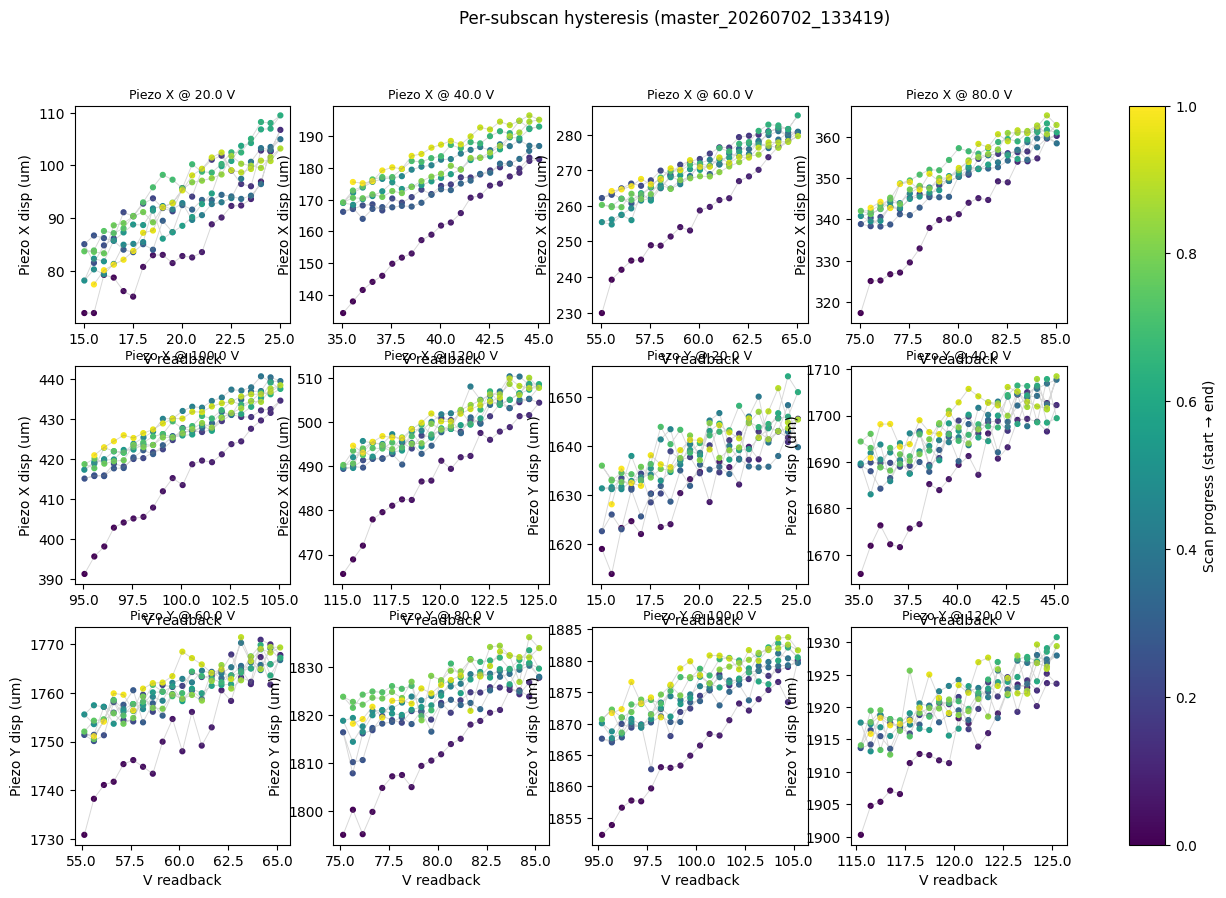

In [19]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Per-subscan hysteresis: one subplot per sub-scan, displacement vs. voltage
# colored by normalized scan progress (0=start -> 1=end) so the rising/falling
# legs (hysteresis loop) are visible and a single colorbar is shared by the grid.
if subscans:
    n = len(subscans)
    ncols = min(4, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows),
                             squeeze=False)
    axes_flat = axes.ravel()
    norm = Normalize(0, 1)
    for ax, (meta, d) in zip(axes_flat, subscans):
        progress = np.linspace(0, 1, len(d))  # time order, normalized per sub-scan
        ax.scatter(d["voltage_readback_V"], d[meta["pos_col"]], c=progress,
                   cmap="viridis", norm=norm, s=12)
        ax.plot(d["voltage_readback_V"], d[meta["pos_col"]], "-", color="gray",
                alpha=0.3, linewidth=0.7)
        ax.set_title(f"Piezo {meta['axis']} @ {meta['center']:.1f} V", fontsize=9)
        ax.set_xlabel("V readback")
        ax.set_ylabel(f"Piezo {meta['axis']} disp (um)")
    # blank any unused subplots in the grid
    for ax in axes_flat[n:]:
        ax.axis("off")

    sm = ScalarMappable(norm=norm, cmap="viridis")
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes_flat.tolist())
    cbar.set_label("Scan progress (start → end)")

    fig.suptitle(f"Per-subscan hysteresis ({os.path.basename(MASTER_DIR)})")
    plt.show()
else:
    print("No sub-scans to plot.")

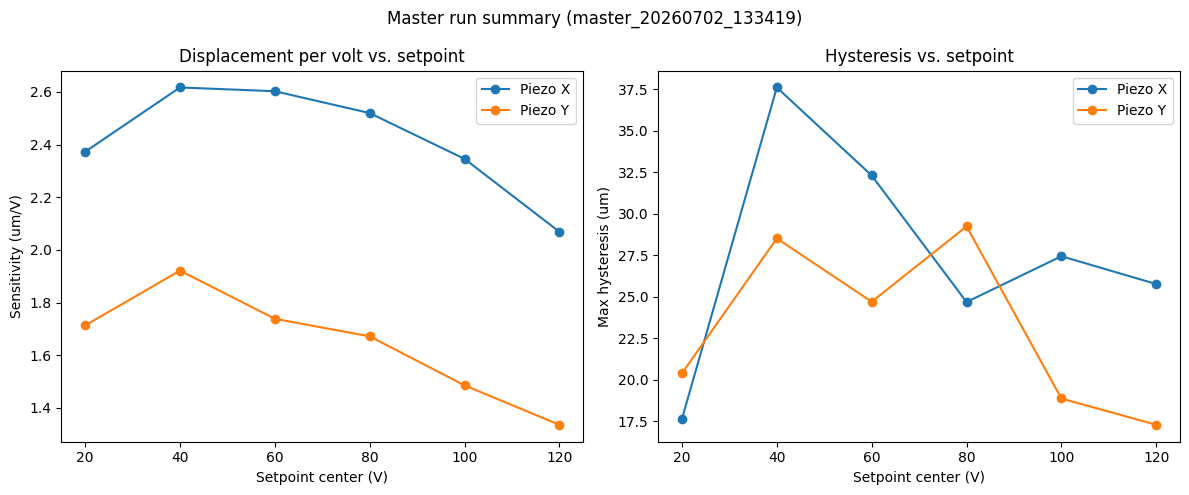

In [20]:
# Headline result of a master run: displacement-per-volt (sensitivity) and
# hysteresis as a function of operating setpoint, one series per piezo axis.
if not summary.empty:
    fig, (ax_s, ax_h) = plt.subplots(1, 2, figsize=(12, 5))
    for axis, g in summary.groupby("axis"):
        ax_s.plot(g["center_V"], g["sensitivity_um_per_V"], "o-", label=f"Piezo {axis}")
        ax_h.plot(g["center_V"], g["hysteresis_um"], "o-", label=f"Piezo {axis}")

    ax_s.set_xlabel("Setpoint center (V)")
    ax_s.set_ylabel("Sensitivity (um/V)")
    ax_s.set_title("Displacement per volt vs. setpoint")
    ax_s.legend()

    ax_h.set_xlabel("Setpoint center (V)")
    ax_h.set_ylabel("Max hysteresis (um)")
    ax_h.set_title("Hysteresis vs. setpoint")
    ax_h.legend()

    fig.suptitle(f"Master run summary ({os.path.basename(MASTER_DIR)})")
    fig.tight_layout()
    plt.show()
else:
    print("No summary to plot.")